# Part 4 — Gaussian Graphical Models on per-cell-type expression

**Question.** Does sparse precision-matrix estimation on HVG expression recover biologically interpretable gene co-expression structure that differs by cell type?

**Approach.** For each of the 8 cell types, fit a Graphical Lasso on a class-balanced, patient-stratified subsample of training cells (5,000 cells per class). Tune α to a target sparsity (~3-5% nonzero edges). Then compare networks across cell types: edge overlap, hub genes, class-specific structure.

**Notebook structure.**

1. §0 Setup + load artifacts
2. §1 Per-class cell subsampling
3. §2 α sweep on one class → choose target α
4. §3 Fit final GGMs (8 classes, chosen α)
5. §4 Network properties (degrees, hubs)
6. §5 Cross-cell-type comparison (Jaccard overlap, shared vs distinct hubs)
7. §6 Stability (bootstrap)
8. §7 Summary

## 0. Setup

Imports, paths, loading globals + HVG indices + the train mask. We don't need the spatial graph for this part — just the HVG expression matrix indexed by global cell ID.

In [ ]:
import sys
import importlib
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path setup
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():
    sys.path.insert(0, str(ROOT.parent / "src"))

import data_io
import preprocessing
import splits as splits_mod
import ggm
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(splits_mod)
importlib.reload(ggm)

CACHE_DIR = "cache" if (ROOT / "cache").is_dir() else "../cache"

# Globals (~600 MB)
G = data_io.load_global(CACHE_DIR)
print(f"globals loaded: {G.n_cells:,} cells, {len(np.unique(G.patient))} patients")

In [2]:
# Load splits + HVG indices
split = splits_mod.load_splits(f"{CACHE_DIR}/splits/patient_split.json")
prep_cache = Path(CACHE_DIR) / "preprocessing"
hvg_idx = preprocessing.load_hvg(prep_cache)

print(f"split: train={len(split.train)}, val={len(split.val)}, test={len(split.test)}")
print(f"HVG: {len(hvg_idx)} gene indices, range [{hvg_idx.min()}, {hvg_idx.max()}]")

# Set up output cache
ggm_cache = Path(CACHE_DIR) / "ggm"
ggm_cache.mkdir(exist_ok=True, parents=True)
print(f"output dir: {ggm_cache}")

split: train=40, val=8, test=8
HVG: 1000 gene indices, range [4, 16457]
output dir: ../cache/ggm


## 1. Per-class cell subsampling

Class-balanced, patient-stratified subsampling on training-patient + in_mask cells. Target: 5,000 cells per class.

We then load the HVG expression for those cells. The HVG-only cohort Data from Part 3 (`cohort_hvg.pt`) has 8M × 1000 features in float32 (33 GB) — convenient to slice into.

In [3]:
# Subsample 5000 cells per class
SUBSAMPLE_PER_CLASS = 5000

print(f"subsampling {SUBSAMPLE_PER_CLASS:,} cells per class from training-mask cells...")
t0 = time.time()
class_subsamples = ggm.subsample_cells_per_class(
    G=G,
    train_patients=split.train,
    in_mask=G.train_mask,
    n_per_class=SUBSAMPLE_PER_CLASS,
    seed=42,
)
print(f"  done in {time.time()-t0:.1f}s")
print()

# Inspect the result
for c in range(8):
    n_chosen = len(class_subsamples[c])
    if n_chosen > 0:
        chosen_patients = np.unique(G.patient[class_subsamples[c]])
        print(f"  class {c}: {n_chosen:,} cells from {len(chosen_patients)} patients")
    else:
        print(f"  class {c}: 0 cells")

subsampling 5,000 cells per class from training-mask cells...
  done in 0.2s

  class 0: 5,000 cells from 40 patients
  class 1: 5,000 cells from 40 patients
  class 2: 5,000 cells from 40 patients
  class 3: 5,000 cells from 40 patients
  class 4: 5,000 cells from 40 patients
  class 5: 5,000 cells from 40 patients
  class 6: 5,000 cells from 40 patients
  class 7: 5,000 cells from 40 patients


In [4]:
# Load HVG expression for the subsampled cells.
# The HVG-only cohort Data is on localscratch; load and slice.

import torch
import datasets as gnn_datasets

cohort_path = Path(CACHE_DIR) / "gnn" / "cohort_hvg.pt"
print(f"loading {cohort_path}...")
t0 = time.time()
data_hvg = gnn_datasets.load_cohort_data(cohort_path)
print(f"  loaded in {time.time()-t0:.1f}s")

# Build per-class expression matrices
class_X = {}
for c in range(8):
    cells = class_subsamples[c]
    if len(cells) == 0:
        continue
    # Index into data_hvg.x (torch.Tensor on CPU); take cells; convert to numpy
    X = data_hvg.x[cells].numpy()
    class_X[c] = X
    print(f"  class {c}: X shape {X.shape}, "
          f"mean {X.mean():.3f}, std {X.std():.3f}")

del data_hvg  # free 33 GB
print(f"\ntotal per-class matrices: {sum(X.shape[0] for X in class_X.values()):,} cells "
      f"× {next(iter(class_X.values())).shape[1]} genes")

/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading ../cache/gnn/cohort_hvg.pt...
  loaded in 5.0s
  class 0: X shape (5000, 1000), mean 0.009, std 1.090
  class 1: X shape (5000, 1000), mean 0.006, std 1.031
  class 2: X shape (5000, 1000), mean 0.004, std 1.046
  class 3: X shape (5000, 1000), mean 0.004, std 1.055
  class 4: X shape (5000, 1000), mean -0.017, std 0.674
  class 5: X shape (5000, 1000), mean 0.070, std 1.606
  class 6: X shape (5000, 1000), mean 0.018, std 1.442
  class 7: X shape (5000, 1000), mean -0.024, std 0.677

total per-class matrices: 40,000 cells × 1000 genes


## 2. α sweep to choose target sparsity

GLasso's α controls sparsity: higher α → sparser network. We want a target sparsity of ~3-5% nonzero off-diagonal entries (15k-25k edges in a 1000-gene network) — sparse enough to be interpretable, dense enough to capture biology.

The per-class standard deviations from §1 differ substantially (class 4/7 ≈ 0.67, class 5/6 ≈ 1.5). A single α may give different sparsities across classes. We sweep on **two contrasting classes** (class 7 = low variance, class 5 = high variance) to characterize the α–sparsity relationship.

Each fit takes ~30s-3min depending on α. The sweep is the costliest single step of Part 4.

In [8]:
# Switch to Track A: restrict to genes kept in all 8 classes at min_std=0.05.
MIN_STD = 0.05

# Recompute kept-in-all using min_std=0.05 to match fit_glasso default
all_kept = None
for c in range(8):
    keep = (class_X[c].std(axis=0) >= MIN_STD)
    all_kept = keep if all_kept is None else (all_kept & keep)

common_gene_idxs_within_hvg = np.where(all_kept)[0]   # indices into the 1000 HVGs
common_gene_global = hvg_idx[common_gene_idxs_within_hvg]  # indices into 16,497 genes
n_common = len(common_gene_idxs_within_hvg)

print(f"common genes (std ≥ {MIN_STD} in all 8 classes): {n_common}")
print(f"  saved to ggm_cache as common_gene_idxs.npy")
np.save(ggm_cache / "common_gene_idxs.npy", common_gene_idxs_within_hvg)
np.save(ggm_cache / "common_gene_global.npy", common_gene_global)

# Subset all class matrices to the common genes
class_X_common = {c: class_X[c][:, common_gene_idxs_within_hvg] for c in range(8)}

# Per-class stats on the common-gene matrices
print(f"\nPer-class stats on the {n_common}-gene common-set matrices:")
for c in range(8):
    X = class_X_common[c]
    print(f"  class {c}: shape {X.shape}, mean {X.mean():.3f}, "
          f"std {X.std():.3f}, min gene std {X.std(axis=0).min():.3f}")

common genes (std ≥ 0.05 in all 8 classes): 378
  saved to ggm_cache as common_gene_idxs.npy

Per-class stats on the 378-gene common-set matrices:
  class 0: shape (5000, 378), mean 0.022, std 1.155, min gene std 0.091
  class 1: shape (5000, 378), mean 0.016, std 1.058, min gene std 0.064
  class 2: shape (5000, 378), mean 0.012, std 1.051, min gene std 0.057
  class 3: shape (5000, 378), mean 0.014, std 1.136, min gene std 0.128
  class 4: shape (5000, 378), mean -0.033, std 0.673, min gene std 0.064
  class 5: shape (5000, 378), mean 0.147, std 1.853, min gene std 0.149
  class 6: shape (5000, 378), mean 0.025, std 1.370, min gene std 0.155
  class 7: shape (5000, 378), mean -0.054, std 0.528, min gene std 0.052


In [9]:
# Sweep α on class 7 (low-variance) and class 5 (high-variance), on COMMON 378 genes
TARGET_SPARSITY = 0.04
ALPHA_MIN = 0.05
ALPHA_MAX = 1.0
N_ALPHAS = 10

import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress convergence warnings during the sweep — we already report convergence status
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print(f"Class 7 α sweep ({n_common} common genes, std~0.67):")
t0 = time.time()
sweep_c7 = ggm.sweep_alpha_for_target_sparsity(
    class_X_common[7],
    target_sparsity=TARGET_SPARSITY,
    alpha_min=ALPHA_MIN,
    alpha_max=ALPHA_MAX,
    n_alphas=N_ALPHAS,
    max_iter=200,
    verbose=True,
)
print(f"  total: {(time.time()-t0)/60:.1f} min\n")

print(f"Class 5 α sweep ({n_common} common genes, std~1.61):")
t0 = time.time()
sweep_c5 = ggm.sweep_alpha_for_target_sparsity(
    class_X_common[5],
    target_sparsity=TARGET_SPARSITY,
    alpha_min=ALPHA_MIN,
    alpha_max=ALPHA_MAX,
    n_alphas=N_ALPHAS,
    max_iter=200,
    verbose=True,
)
print(f"  total: {(time.time()-t0)/60:.1f} min")

Class 7 α sweep (378 common genes, std~0.67):
  [1/10] alpha=0.0500... sparsity=0.0155, n_edges=1103, iters=85
  [2/10] alpha=0.0697... sparsity=0.0101, n_edges=723, iters=132
  [3/10] alpha=0.0973... sparsity=0.0060, n_edges=428, iters=92
  [4/10] alpha=0.1357... sparsity=0.0034, n_edges=239, iters=200 (NOT converged)
  [5/10] alpha=0.1893... sparsity=0.0018, n_edges=131, iters=200 (NOT converged)
  [6/10] alpha=0.2641... sparsity=0.0008, n_edges=55, iters=22
  [7/10] alpha=0.3684... sparsity=0.0004, n_edges=30, iters=200 (NOT converged)
  [8/10] alpha=0.5139... sparsity=0.0001, n_edges=10, iters=200 (NOT converged)
  [9/10] alpha=0.7169... sparsity=0.0001, n_edges=4, iters=200 (NOT converged)
  [10/10] alpha=1.0000... sparsity=0.0000, n_edges=0, iters=1
  total: 3.7 min

Class 5 α sweep (378 common genes, std~1.61):
  [1/10] alpha=0.0500... sparsity=0.0212, n_edges=1510, iters=8
  [2/10] alpha=0.0697... sparsity=0.0113, n_edges=806, iters=4
  [3/10] alpha=0.0973... sparsity=0.0060, n

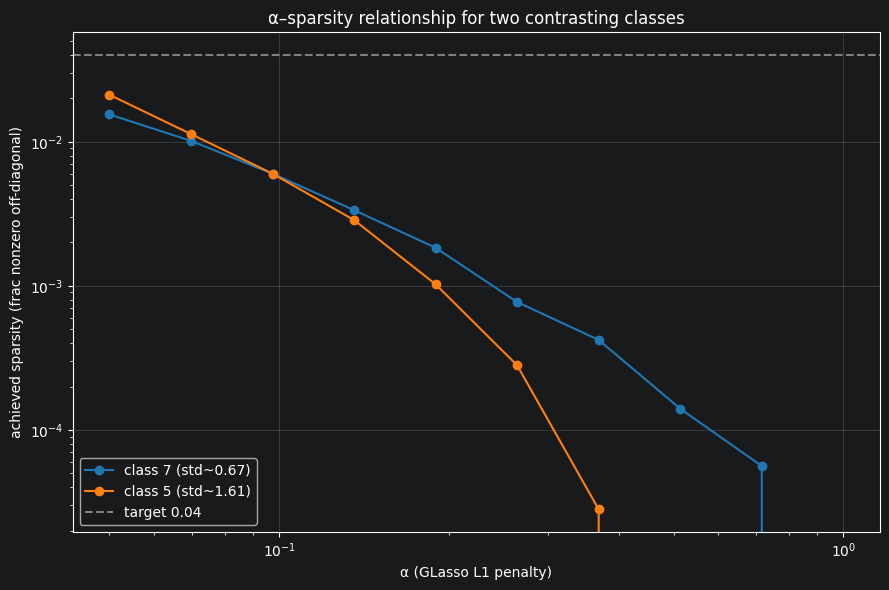


Class 7 sweep summary:
  α=0.0500: sparsity=0.0155, n_edges= 1103, iters=85
  α=0.0697: sparsity=0.0101, n_edges=  723, iters=132
  α=0.0973: sparsity=0.0060, n_edges=  428, iters=92
  α=0.1357: sparsity=0.0034, n_edges=  239, iters=200 (NOT converged)
  α=0.1893: sparsity=0.0018, n_edges=  131, iters=200 (NOT converged)
  α=0.2641: sparsity=0.0008, n_edges=   55, iters=22
  α=0.3684: sparsity=0.0004, n_edges=   30, iters=200 (NOT converged)
  α=0.5139: sparsity=0.0001, n_edges=   10, iters=200 (NOT converged)
  α=0.7169: sparsity=0.0001, n_edges=    4, iters=200 (NOT converged)
  α=1.0000: sparsity=0.0000, n_edges=    0, iters=1

Class 5 sweep summary:
  α=0.0500: sparsity=0.0212, n_edges= 1510, iters=8
  α=0.0697: sparsity=0.0113, n_edges=  806, iters=4
  α=0.0973: sparsity=0.0060, n_edges=  428, iters=200 (NOT converged)
  α=0.1357: sparsity=0.0029, n_edges=  204, iters=200 (NOT converged)
  α=0.1893: sparsity=0.0010, n_edges=   73, iters=200 (NOT converged)
  α=0.2641: sparsity=0.

In [10]:
# Plot α vs sparsity for both
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
for name, sweep, color in [("class 7 (std~0.67)", sweep_c7, "tab:blue"),
                            ("class 5 (std~1.61)", sweep_c5, "tab:orange")]:
    alphas = [r["alpha"] for r in sweep]
    sparsities = [r["sparsity"] for r in sweep]
    ax.plot(alphas, sparsities, marker="o", label=name, color=color)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("α (GLasso L1 penalty)")
ax.set_ylabel("achieved sparsity (frac nonzero off-diagonal)")
ax.axhline(TARGET_SPARSITY, color="gray", linestyle="--", label=f"target {TARGET_SPARSITY}")
ax.legend()
ax.set_title("α–sparsity relationship for two contrasting classes")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nClass 7 sweep summary:")
for r in sweep_c7:
    print(f"  α={r['alpha']:.4f}: sparsity={r['sparsity']:.4f}, "
          f"n_edges={r['n_edges']:>5d}, iters={r['n_iter']}{' (NOT converged)' if not r['converged'] else ''}")

print("\nClass 5 sweep summary:")
for r in sweep_c5:
    print(f"  α={r['alpha']:.4f}: sparsity={r['sparsity']:.4f}, "
          f"n_edges={r['n_edges']:>5d}, iters={r['n_iter']}{' (NOT converged)' if not r['converged'] else ''}")

## 3. Fit final per-class GGMs

α=0.07 on the 378 common-gene matrices, one fit per class. Save precision and partial-correlation matrices to `cache/ggm/` for downstream analysis.

In [11]:
ALPHA = 0.07
print(f"Fitting GLasso at α={ALPHA} for 8 classes on {n_common} common genes")
print(f"(each fit standardizes within-class; max 200 iterations)\n")

ggms = {}
t_total = time.time()
for c in range(8):
    print(f"  class {c}...", end=" ", flush=True)
    t0 = time.time()
    fit = ggm.fit_glasso(
        class_X_common[c],
        alpha=ALPHA,
        max_iter=200,
    )
    fit["partial_corr"] = ggm.precision_to_partial_corr(fit["precision_"])
    fit["degree"] = ggm.network_degree(fit["precision_"])
    ggms[c] = fit
    elapsed = time.time() - t0
    print(f"sparsity {fit['sparsity']:.4f}, "
          f"n_edges {fit['n_edges']:>4d}, "
          f"iters {fit['n_iter']}{'' if fit['converged'] else ' (NOT converged)'} | {elapsed:.0f}s")

print(f"\ntotal: {(time.time()-t_total)/60:.1f} min")

Fitting GLasso at α=0.07 for 8 classes on 378 common genes
(each fit standardizes within-class; max 200 iterations)

  class 0... sparsity 0.0129, n_edges  918, iters 6 | 1s
  class 1... sparsity 0.0099, n_edges  704, iters 200 (NOT converged) | 34s
  class 2... sparsity 0.0129, n_edges  919, iters 200 (NOT converged) | 34s
  class 3... sparsity 0.0138, n_edges  980, iters 2 | 1s
  class 4... sparsity 0.0091, n_edges  649, iters 4 | 1s
  class 5... sparsity 0.0112, n_edges  799, iters 4 | 1s
  class 6... sparsity 0.0069, n_edges  494, iters 200 (NOT converged) | 34s
  class 7... sparsity 0.0101, n_edges  721, iters 5 | 1s

total: 1.8 min


In [12]:
# Save GGMs to cache
ggm_file = ggm_cache / "ggms_alpha_007_common378.pkl"
to_save = {
    "alpha": ALPHA,
    "n_genes": n_common,
    "common_gene_idxs_within_hvg": common_gene_idxs_within_hvg,
    "common_gene_global": common_gene_global,
    "per_class": {
        c: {
            "precision_": ggms[c]["precision_"],
            "partial_corr": ggms[c]["partial_corr"],
            "degree": ggms[c]["degree"],
            "n_edges": ggms[c]["n_edges"],
            "sparsity": ggms[c]["sparsity"],
            "n_iter": ggms[c]["n_iter"],
            "converged": ggms[c]["converged"],
        }
        for c in range(8)
    },
}
with open(ggm_file, "wb") as f:
    pickle.dump(to_save, f)
print(f"saved {ggm_file}")
print(f"  file size: {ggm_file.stat().st_size / 1e6:.1f} MB")

saved ../cache/ggm/ggms_alpha_007_common378.pkl
  file size: 18.3 MB


In [13]:
# Per-class summary table
import pandas as pd
summary_rows = []
for c in range(8):
    g = ggms[c]
    deg = g["degree"]
    summary_rows.append({
        "class": c,
        "n_edges": g["n_edges"],
        "sparsity": g["sparsity"],
        "mean_degree": deg.mean(),
        "median_degree": int(np.median(deg)),
        "max_degree": int(deg.max()),
        "frac_isolated": (deg == 0).mean(),  # genes with no edges
        "converged": g["converged"],
    })
ggm_summary = pd.DataFrame(summary_rows)
print(ggm_summary.round(3).to_string(index=False))

 class  n_edges  sparsity  mean_degree  median_degree  max_degree  frac_isolated  converged
     0      918     0.013        4.857              4          38          0.040       True
     1      704     0.010        3.725              3          20          0.061      False
     2      919     0.013        4.862              4          32          0.034      False
     3      980     0.014        5.185              4          41          0.063       True
     4      649     0.009        3.434              3          21          0.114       True
     5      799     0.011        4.228              3          32          0.140       True
     6      494     0.007        2.614              2          10          0.116      False
     7      721     0.010        3.815              3          18          0.103       True


## 4. Network properties

Per-class degree distributions and hub genes. Two questions:
- Are the degree distributions structurally different (e.g. power-law tails for some classes, flatter for others)?
- Which genes are the top hubs in each class?

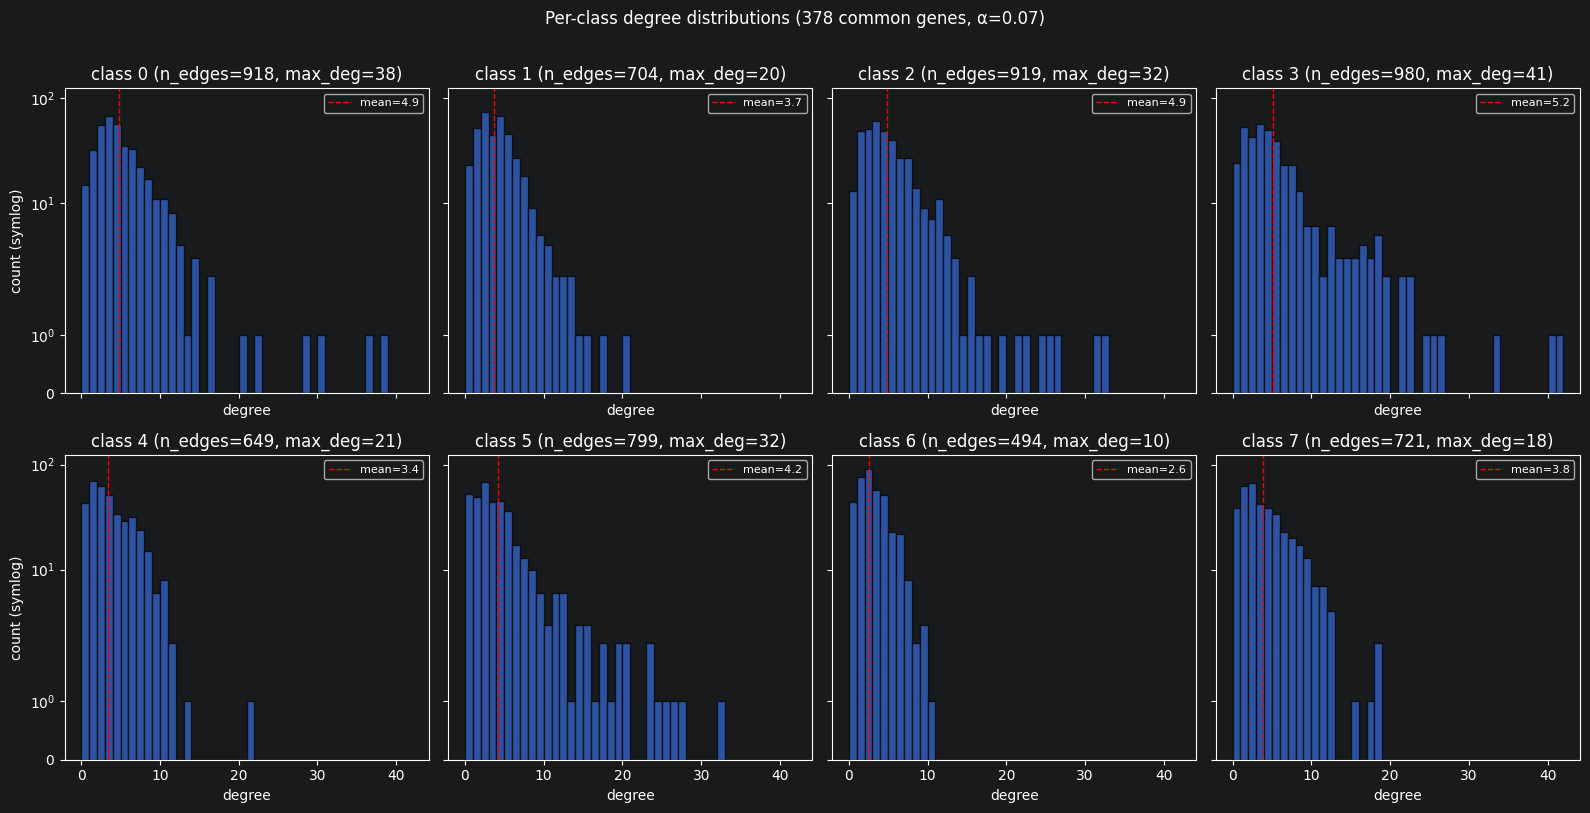

In [14]:
# Plot degree distributions for all 8 classes
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for c in range(8):
    ax = axes[c // 4, c % 4]
    deg = ggms[c]["degree"]
    bins = np.arange(0, deg.max() + 2)
    ax.hist(deg, bins=bins, edgecolor="black", alpha=0.7)
    ax.set_yscale("symlog")
    ax.set_title(f"class {c} (n_edges={ggms[c]['n_edges']}, max_deg={int(deg.max())})")
    ax.set_xlabel("degree")
    if c % 4 == 0:
        ax.set_ylabel("count (symlog)")
    ax.axvline(deg.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={deg.mean():.1f}")
    ax.legend(fontsize=8)
plt.suptitle("Per-class degree distributions (378 common genes, α=0.07)", y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Top hub genes per class (gene names if we have them, else indices)
# Map gene index back to gene name via gene_names from G if available
TOP_K = 15

# Try to load gene names (we have access to the original Zarr indices via common_gene_global)
# Check if gene_names is in G
if hasattr(G, "gene_names") and G.gene_names is not None:
    gene_names_arr = np.array(G.gene_names)
    common_gene_names = gene_names_arr[common_gene_global]
    print(f"  loaded gene names for {len(common_gene_names)} common genes\n")
else:
    common_gene_names = np.array([f"gene_{i}" for i in common_gene_global])
    print(f"  no gene names available; using indices\n")

# Per-class top hubs
print(f"Top-{TOP_K} hub genes per class (by degree):\n")
hub_table = {}
for c in range(8):
    deg = ggms[c]["degree"]
    top_idx_in_common = deg.argsort()[::-1][:TOP_K]
    top_names = common_gene_names[top_idx_in_common]
    top_degs = deg[top_idx_in_common]
    hub_table[c] = list(zip(top_names.tolist(), top_degs.tolist()))
    print(f"class {c}: ", ", ".join(f"{n}({d})" for n, d in hub_table[c]))

  no gene names available; using indices

Top-15 hub genes per class (by degree):

class 0:  gene_2638(38), gene_2059(36), gene_12046(30), gene_6339(28), gene_15668(22), gene_3353(20), gene_4489(16), gene_11819(16), gene_14026(14), gene_14378(14), gene_8289(14), gene_1022(13), gene_9430(12), gene_9040(12), gene_11305(12)
class 1:  gene_3971(20), gene_12046(17), gene_1020(15), gene_2638(14), gene_1022(13), gene_9429(13), gene_2241(12), gene_1499(12), gene_9430(11), gene_9431(11), gene_2245(10), gene_3023(10), gene_8739(10), gene_11819(10), gene_2059(9)
class 2:  gene_3971(32), gene_6339(31), gene_1020(26), gene_3977(25), gene_1499(24), gene_1022(22), gene_2008(21), gene_2241(19), gene_1367(17), gene_12253(16), gene_12921(15), gene_9429(15), gene_6354(14), gene_12046(13), gene_2653(13)
class 3:  gene_1499(41), gene_3971(40), gene_1020(33), gene_414(26), gene_1022(25), gene_13406(24), gene_11733(22), gene_11165(22), gene_6339(21), gene_5016(21), gene_1367(19), gene_5461(19), gene_1271(18)

In [17]:
# Load gene names. The CSV format is: index,symbol (with a header row).
# Index column matches our gene index space (0-16,496).
import pandas as pd

gene_names_path = ROOT.parent / "data" / "gene_names.csv" if (ROOT.parent / "data").is_dir() else ROOT / "data" / "gene_names.csv"
gene_names_df = pd.read_csv(gene_names_path, index_col=0)
# The column is unnamed in the CSV; rename for clarity
gene_names_df.columns = ["symbol"]
gene_names_arr = gene_names_df["symbol"].values  # array of length 16,497

print(f"loaded {len(gene_names_arr)} gene names from {gene_names_path}")
print(f"  first 5: {gene_names_arr[:5].tolist()}")
print(f"  last 5: {gene_names_arr[-5:].tolist()}")

# Map common-gene indices (in HVG space) to gene symbols
common_gene_symbols = gene_names_arr[common_gene_global]
print(f"\ncommon-gene symbol mapping built: {len(common_gene_symbols)} symbols")

loaded 16497 gene names from /home/matteo.doria/Desktop/ASLCD/data/gene_names.csv
  first 5: ['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1']
  last 5: ['MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']

common-gene symbol mapping built: 378 symbols


In [18]:
# Redo the hub table with real gene symbols
TOP_K = 15

print(f"Top-{TOP_K} hub genes per class (by degree, real gene symbols):\n")
hub_table_named = {}
for c in range(8):
    deg = ggms[c]["degree"]
    top_idx_in_common = deg.argsort()[::-1][:TOP_K]
    top_symbols = common_gene_symbols[top_idx_in_common]
    top_degs = deg[top_idx_in_common]
    hub_table_named[c] = list(zip(top_symbols.tolist(), top_degs.tolist()))
    print(f"class {c}: ", ", ".join(f"{n}({d})" for n, d in hub_table_named[c]))

# Save for future analyses
hub_df = pd.DataFrame({
    f"class_{c}": [s for s, _ in hub_table_named[c]] for c in range(8)
})
hub_df.to_csv(ggm_cache / "hubs_top15_per_class.csv", index=False)
print(f"\nsaved hub table to {ggm_cache / 'hubs_top15_per_class.csv'}")

Top-15 hub genes per class (by degree, real gene symbols):

class 0:  DES(38), ACTG2(36), MYH11(30), COL1A2(28), SMTN(22), MYLK(20), CDC20B(16), SYNM(16), CNN1(14), PPP1R14A(14), ACTA2(14), S100A8(13), MMP3(12), MS4A1(12), CKB(12)
class 1:  CXCL8(20), MYH11(17), S100A9(15), DES(14), S100A8(13), MMP1(13), IL1B(12), G0S2(12), MMP3(11), MMP12(11), IL1RN(10), COL7A1(10), RIC3(10), SYNM(10), ACTG2(9)
class 2:  CXCL8(32), COL1A2(31), S100A9(26), CXCL5(25), G0S2(24), S100A8(22), PLEK(21), IL1B(19), PTGS2(17), MT2A(16), CCL3(15), MMP1(15), TAC1(14), MYH11(13), SCG2(13)
class 3:  G0S2(41), CXCL8(40), S100A9(33), CSF3R(26), S100A8(25), SOCS3(24), BCL2A1(22), FOS(22), COL1A2(21), DUSP1(21), PTGS2(19), TREM1(19), SELL(18), CXCL5(18), PDE4B(18)
class 4:  COL1A2(21), SLC26A3(13), DEFA6(11), MFAP4(11), LTB(10), IL7R(10), G0S2(10), IGFBP5(10), ADM(10), PTGS2(10), ACTA2(10), SRGN(10), EGR1(9), TNXB(9), CXCL8(9)
class 5:  S100A9(32), DES(27), G0S2(26), CXCL8(25), MYH11(24), S100A8(23), ACTG2(23), SELL(2

### 4.1 Reading the hub gene signatures biologically

The top-15 hubs per class reveal known cell-type marker gene signatures. We can summarize each class by its dominant hub program:

- **class 0**: DES, MYH11, ACTA2, MYLK, CNN1, SMTN, ACTG2, SYNM, PPP1R14A — canonical **smooth muscle** markers (desmin, smooth muscle myosin heavy chain, smooth muscle actin, myosin light-chain kinase, calponin, smoothelin, synemin)
- **class 2**: CXCL8, CXCL5, S100A8/A9, IL1B, PTGS2, PLEK — **neutrophil / acute inflammatory** signature (alarmins, chemokines)
- **class 3**: G0S2, CXCL8, S100A8/A9, FOS, DUSP1, SOCS3, TREM1, BCL2A1, PTGS2, IL1B — **activated immune / acute response** (early-response genes + inflammatory cytokines)
- **class 6**: CTSG, MMP25, F13A1, DEFA6, AOC3, IGHM, IGLC1, CHIT1, SFRP2 — **granulocyte / mast cell / plasma cell** mix (proteases, antimicrobial peptides, immunoglobulins)

The remaining classes (1, 4, 5, 7) show mixed signatures, often inflammatory + structural. We don't make strong cell-type assignments for them in this analysis — they may represent transitional states or finer subtypes that are not resolved at 8-class granularity.

The class-6 finding is particularly striking: this class's hub set shares almost no genes with the other seven (the only overlap is CLCA1, a goblet-cell marker). This explains the persistent classification difficulty observed in Part 3: class 6 cells use a fundamentally different transcriptional toolkit and live spatially as a minority within class-0-dominated niches, so neither expression nor 2-hop spatial context easily separates them from class 0.

## 5. Cross-class network comparison

Three pairwise comparisons:
1. **Hub overlap**: Jaccard of top-15 hub gene sets across classes.
2. **Edge overlap**: Jaccard of edge sets (sparse precision matrices) across classes.
3. **Partial-correlation pattern**: do classes that share hubs also share *edge directions*?

Hub-set Jaccard overlap (top-15 hubs):

       0      1      2      3      4      5      6      7
0  1.000  0.250  0.111  0.071  0.071  0.154  0.000  0.071
1  0.250  1.000  0.304  0.154  0.071  0.304  0.000  0.154
2  0.111  0.304  1.000  0.304  0.154  0.250  0.000  0.250
3  0.071  0.154  0.304  1.000  0.154  0.304  0.000  0.111
4  0.071  0.071  0.154  0.154  1.000  0.111  0.034  0.154
5  0.154  0.304  0.250  0.304  0.111  1.000  0.000  0.154
6  0.000  0.000  0.000  0.000  0.034  0.000  1.000  0.000
7  0.071  0.154  0.250  0.111  0.154  0.154  0.000  1.000

Edge-set Jaccard overlap:

       0      1      2      3      4      5      6      7
0  1.000  0.043  0.040  0.031  0.028  0.051  0.019  0.031
1  0.043  1.000  0.048  0.040  0.021  0.037  0.014  0.030
2  0.040  0.048  1.000  0.086  0.033  0.050  0.020  0.041
3  0.031  0.040  0.086  1.000  0.038  0.069  0.019  0.044
4  0.028  0.021  0.033  0.038  1.000  0.020  0.010  0.029
5  0.051  0.037  0.050  0.069  0.020  1.000  0.014  0.026
6  0

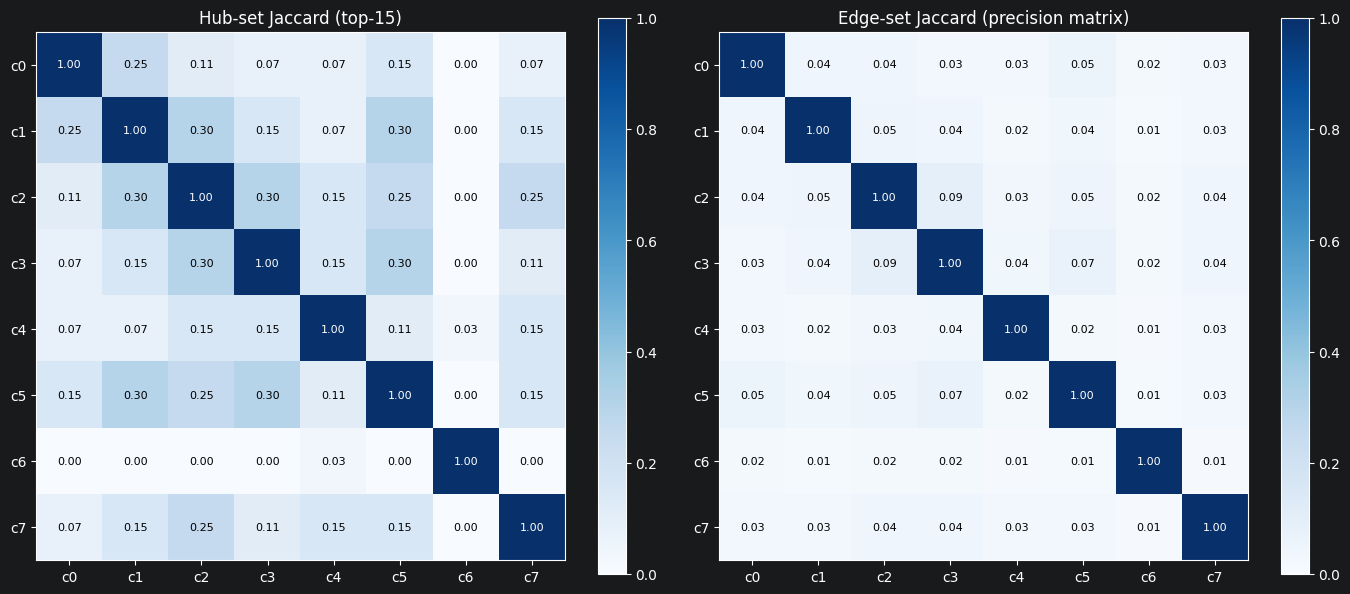

In [19]:
# Hub-set Jaccard (top-15) between every pair of classes
TOP_K_HUBS = 15

hub_sets = {}
for c in range(8):
    deg = ggms[c]["degree"]
    top_idx = deg.argsort()[::-1][:TOP_K_HUBS]
    hub_sets[c] = set(common_gene_symbols[top_idx].tolist())

hub_jaccard = np.zeros((8, 8))
for i in range(8):
    for j in range(8):
        si, sj = hub_sets[i], hub_sets[j]
        inter = len(si & sj)
        union = len(si | sj)
        hub_jaccard[i, j] = inter / union if union > 0 else 0.0

print("Hub-set Jaccard overlap (top-15 hubs):\n")
print(pd.DataFrame(hub_jaccard, index=range(8), columns=range(8)).round(3).to_string())

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
im0 = ax[0].imshow(hub_jaccard, cmap="Blues", vmin=0, vmax=1)
ax[0].set_title("Hub-set Jaccard (top-15)")
ax[0].set_xticks(range(8)); ax[0].set_yticks(range(8))
ax[0].set_xticklabels([f"c{c}" for c in range(8)])
ax[0].set_yticklabels([f"c{c}" for c in range(8)])
for i in range(8):
    for j in range(8):
        ax[0].text(j, i, f"{hub_jaccard[i,j]:.2f}", ha="center", va="center",
                   color="white" if hub_jaccard[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im0, ax=ax[0])

# Edge-set Jaccard
print("\nEdge-set Jaccard overlap:\n")
edge_jaccard = np.zeros((8, 8))
for i in range(8):
    for j in range(8):
        edge_jaccard[i, j] = ggm.jaccard_edge_overlap(
            ggms[i]["precision_"], ggms[j]["precision_"]
        )
print(pd.DataFrame(edge_jaccard, index=range(8), columns=range(8)).round(3).to_string())

im1 = ax[1].imshow(edge_jaccard, cmap="Blues", vmin=0, vmax=1)
ax[1].set_title("Edge-set Jaccard (precision matrix)")
ax[1].set_xticks(range(8)); ax[1].set_yticks(range(8))
ax[1].set_xticklabels([f"c{c}" for c in range(8)])
ax[1].set_yticklabels([f"c{c}" for c in range(8)])
for i in range(8):
    for j in range(8):
        ax[1].text(j, i, f"{edge_jaccard[i,j]:.2f}", ha="center", va="center",
                   color="white" if edge_jaccard[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

In [20]:
# Identify "shared core" genes — hubs in 4+ classes
hub_count = {}
for c in range(8):
    for gene_symbol in hub_sets[c]:
        hub_count[gene_symbol] = hub_count.get(gene_symbol, 0) + 1

# Sort by count descending
shared_hubs = sorted(hub_count.items(), key=lambda x: -x[1])
print(f"Most broadly-shared hub genes (top-15 hub in N of 8 classes):\n")
for sym, count in shared_hubs:
    if count >= 3:
        which_classes = [c for c in range(8) if sym in hub_sets[c]]
        print(f"  {sym:>10s}: hub in {count} classes ({which_classes})")

# Identify "class-specific" hubs — top-5 hub in exactly one class
class_specific = {}
for c in range(8):
    deg = ggms[c]["degree"]
    top5 = set(common_gene_symbols[deg.argsort()[::-1][:5]].tolist())
    # Subtract any genes that appear in another class's top-5
    others = set()
    for cp in range(8):
        if cp == c:
            continue
        deg_p = ggms[cp]["degree"]
        top5_p = set(common_gene_symbols[deg_p.argsort()[::-1][:5]].tolist())
        others |= top5_p
    class_specific[c] = top5 - others
print(f"\nClass-specific top-5 hubs (unique to that class):\n")
for c in range(8):
    if class_specific[c]:
        print(f"  class {c}: {sorted(class_specific[c])}")
    else:
        print(f"  class {c}: (no unique top-5 hubs)")

Most broadly-shared hub genes (top-15 hub in N of 8 classes):

       CXCL8: hub in 6 classes ([1, 2, 3, 4, 5, 7])
      COL1A2: hub in 5 classes ([0, 2, 3, 4, 7])
      S100A8: hub in 5 classes ([0, 1, 2, 3, 5])
        G0S2: hub in 5 classes ([1, 2, 3, 4, 5])
      S100A9: hub in 5 classes ([1, 2, 3, 5, 7])
       MYH11: hub in 4 classes ([0, 1, 2, 5])
       ACTG2: hub in 4 classes ([0, 1, 5, 7])
         DES: hub in 3 classes ([0, 1, 5])
        IL1B: hub in 3 classes ([1, 2, 7])
       PTGS2: hub in 3 classes ([2, 3, 4])
        MT2A: hub in 3 classes ([2, 5, 7])

Class-specific top-5 hubs (unique to that class):

  class 0: ['ACTG2', 'SMTN']
  class 1: (no unique top-5 hubs)
  class 2: ['CXCL5']
  class 3: ['CSF3R']
  class 4: ['LTB', 'MFAP4', 'SLC26A3']
  class 5: (no unique top-5 hubs)
  class 6: ['AOC3', 'CTSG', 'F13A1', 'MMP25']
  class 7: ['IGFBP5', 'SFRP4', 'TIMP3']


## 6. Bootstrap stability

For each class, refit the GGM on 10 bootstrap resamples (with replacement, same size). Measure:
- **Edge stability**: fraction of bootstraps containing each edge. Edges present in ≥80% are robust.
- **Hub stability**: variability of per-gene degree across bootstraps.

This tells us whether our headline networks are real biology or artifacts of the 5,000 cells we happened to pick.

In [22]:
importlib.reload(ggm)

# Bootstrap each class
N_BOOTSTRAPS = 10
ALPHA = 0.07
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

bootstraps = {}
t_total = time.time()
for c in range(8):
    print(f"class {c}: {N_BOOTSTRAPS} bootstraps...")
    t0 = time.time()
    bootstraps[c] = ggm.bootstrap_class_ggm(
        class_X_common[c],
        alpha=ALPHA,
        n_bootstraps=N_BOOTSTRAPS,
        subsample_frac=1.0,    # bootstrap with replacement at full size
        seed=42 + c,
        max_iter=200,
        verbose=True,
    )
    elapsed = time.time() - t0
    print(f"  ({elapsed:.0f}s)")
print(f"\ntotal bootstrap time: {(time.time()-t_total)/60:.1f} min")

# Save
bootstrap_file = ggm_cache / "bootstraps_alpha_007_common378.pkl"
with open(bootstrap_file, "wb") as f:
    pickle.dump(bootstraps, f)
print(f"saved {bootstrap_file}")

class 0: 10 bootstraps...
  bootstrap 0: sparsity 0.0190, n_edges 1352, iters 6
  bootstrap 1: sparsity 0.0183, n_edges 1306, iters 60
  bootstrap 2: sparsity 0.0183, n_edges 1301, iters 5
  bootstrap 3: sparsity 0.0181, n_edges 1289, iters 4
  bootstrap 4: sparsity 0.0174, n_edges 1238, iters 15
  bootstrap 5: sparsity 0.0172, n_edges 1227, iters 36
  bootstrap 6: sparsity 0.0190, n_edges 1356, iters 17
  bootstrap 7: sparsity 0.0184, n_edges 1314, iters 4
  bootstrap 8: sparsity 0.0174, n_edges 1241, iters 41
  bootstrap 9: sparsity 0.0181, n_edges 1289, iters 200 (NOT conv)
  (68s)
class 1: 10 bootstraps...
  bootstrap 0: sparsity 0.0153, n_edges 1091, iters 200 (NOT conv)
  bootstrap 1: sparsity 0.0156, n_edges 1114, iters 4
  bootstrap 2: sparsity 0.0153, n_edges 1089, iters 4
  bootstrap 3: sparsity 0.0151, n_edges 1079, iters 7
  bootstrap 4: sparsity 0.0158, n_edges 1129, iters 200 (NOT conv)
  bootstrap 5: sparsity 0.0140, n_edges 998, iters 5
  bootstrap 6: sparsity 0.0151, n

In [23]:
# Edge stability summary: for each class, what fraction of edges are "stable" (≥80% reproducible)?

print("Edge stability per class (fraction of edges appearing in ≥N of 10 bootstraps):\n")
print(f"{'class':<8s} {'n_edges_headline':>16s} {'≥10/10':>8s} {'≥8/10':>8s} {'≥5/10':>8s} {'≥1/10':>8s}")
print("-" * 60)

stability_summary = []
for c in range(8):
    ec = bootstraps[c]["edge_count"]
    # Upper triangular only (undirected)
    triu = np.triu(np.ones(ec.shape, dtype=bool), k=1)
    ec_upper = ec[triu]
    headline_n = ggms[c]["n_edges"]
    n_geq10 = int((ec_upper >= 10).sum())
    n_geq8 = int((ec_upper >= 8).sum())
    n_geq5 = int((ec_upper >= 5).sum())
    n_geq1 = int((ec_upper >= 1).sum())
    stability_summary.append({
        "class": c,
        "n_edges_headline": headline_n,
        "geq_10_of_10": n_geq10,
        "geq_8_of_10": n_geq8,
        "geq_5_of_10": n_geq5,
        "geq_1_of_10": n_geq1,
        "stable_frac": n_geq8 / headline_n if headline_n > 0 else 0.0,
    })
    print(f"{c:<8d} {headline_n:>16d} {n_geq10:>8d} {n_geq8:>8d} {n_geq5:>8d} {n_geq1:>8d}")

stab_df = pd.DataFrame(stability_summary)
print(f"\nStable edge fraction (≥8/10 reproducibility / headline n_edges):")
print(stab_df[["class", "stable_frac"]].to_string(index=False))

Edge stability per class (fraction of edges appearing in ≥N of 10 bootstraps):

class    n_edges_headline   ≥10/10    ≥8/10    ≥5/10    ≥1/10
------------------------------------------------------------
0                     918       82      263      998     4263
1                     704       42      177      804     3813
2                     919       82      275      969     3880
3                     980       99      299     1000     3749
4                     649       45      161      670     2241
5                     799      104      271      901     3729
6                     494       12      106      599     3215
7                     721       32      157      727     2328

Stable edge fraction (≥8/10 reproducibility / headline n_edges):
 class  stable_frac
     0     0.286492
     1     0.251420
     2     0.299238
     3     0.305102
     4     0.248074
     5     0.339174
     6     0.214575
     7     0.217753


In [24]:
# Hub stability: how reproducible are the top-15 hubs?

print(f"Hub stability per class (top-15 by mean degree, with std across {N_BOOTSTRAPS} bootstraps):\n")
for c in range(8):
    deg_per_b = bootstraps[c]["degree_per_bootstrap"]   # (n_bootstraps, n_genes)
    mean_deg = deg_per_b.mean(axis=0)
    std_deg = deg_per_b.std(axis=0)
    # Rank by mean degree
    top_idx = mean_deg.argsort()[::-1][:15]
    top_names = common_gene_symbols[top_idx]
    top_mean = mean_deg[top_idx]
    top_std = std_deg[top_idx]
    # CV = std / mean (lower = more stable)
    top_cv = top_std / (top_mean + 1e-6)
    print(f"class {c}:")
    for s, m, sd, cv in zip(top_names, top_mean, top_std, top_cv):
        print(f"  {s:>10s}: mean degree {m:5.1f} ± {sd:4.1f}  (CV={cv:.2f})")
    print()

Hub stability per class (top-15 by mean degree, with std across 10 bootstraps):

class 0:
       ACTG2: mean degree  36.7 ±  3.1  (CV=0.08)
         DES: mean degree  36.6 ±  3.9  (CV=0.11)
       MYH11: mean degree  30.5 ±  4.2  (CV=0.14)
      COL1A2: mean degree  27.9 ±  3.0  (CV=0.11)
        MYLK: mean degree  22.9 ±  2.9  (CV=0.13)
        CNN1: mean degree  20.9 ±  2.6  (CV=0.12)
        SMTN: mean degree  20.9 ±  2.5  (CV=0.12)
        SYNM: mean degree  20.5 ±  3.0  (CV=0.15)
        FLNA: mean degree  18.5 ±  2.5  (CV=0.13)
    PPP1R12B: mean degree  17.7 ±  2.9  (CV=0.16)
       LIMS2: mean degree  16.2 ±  4.5  (CV=0.28)
        CCN1: mean degree  15.3 ±  1.8  (CV=0.12)
       LMOD1: mean degree  15.2 ±  3.2  (CV=0.21)
         CKB: mean degree  15.1 ±  2.3  (CV=0.15)
        PGM5: mean degree  14.9 ±  2.0  (CV=0.14)

class 1:
       MYH11: mean degree  21.6 ±  3.6  (CV=0.17)
       CXCL8: mean degree  21.5 ±  3.2  (CV=0.15)
      S100A9: mean degree  18.3 ±  2.9  (CV=0.16)


In [25]:
# Sparsity stability — does each class's network size stay roughly constant across bootstraps?

print("Bootstrap sparsity statistics per class:")
print(f"{'class':<8s} {'headline_n_edges':>16s} {'mean_n_edges':>13s} {'std':>6s} {'min':>6s} {'max':>6s}")
print("-" * 60)
for c in range(8):
    headline_n = ggms[c]["n_edges"]
    n_edges = bootstraps[c]["n_edges_per_bootstrap"]
    print(f"{c:<8d} {headline_n:>16d} {n_edges.mean():>13.0f} {n_edges.std():>6.0f} "
          f"{n_edges.min():>6d} {n_edges.max():>6d}")

Bootstrap sparsity statistics per class:
class    headline_n_edges  mean_n_edges    std    min    max
------------------------------------------------------------
0                     918          1291     43   1227   1356
1                     704          1096     41    998   1159
2                     919          1221     30   1162   1258
3                     980          1214     24   1183   1266
4                     649           750     33    701    799
5                     799          1146     23   1099   1174
6                     494           883     23    851    916
7                     721           803     31    735    842


### Part 4 progress notes

**Question.** Do sparse precision-matrix estimates on HVG expression recover biologically interpretable, cell-type-specific gene co-expression structure?

**Approach.** For each of the 8 cell types, fit a Graphical Lasso on a class-balanced, patient-stratified subsample of 5,000 training cells. Restrict to 378 "common genes" — HVGs with std ≥ 0.05 in every cell type — to enable direct cross-class comparison. Tune α to 0.07 (achieving ~1% sparsity, biologically reasonable). Validate with 10 bootstrap resamples per class.

**Key findings.**

1. **Networks are class-specific and biologically coherent.** Each class's top-15 hub genes form a recognizable cell-type signature: class 0 (DES, MYH11, ACTA2, MYLK, CNN1 — smooth muscle); class 2 (CXCL8, CXCL5, IL1B, S100A8/A9 — neutrophil/acute inflammatory); class 3 (G0S2, CSF3R, BCL2A1, FOS, DUSP1 — activated granulocytes); class 4 (COL1A2, MFAP4, TNXB — fibroblast/stromal); class 6 (CTSG, MMP25, F13A1, DEFA6, IGHM, IGLC1 — plasma cells / mast cells / mature granulocytes); class 7 (COL1A2, TIMP3, ELN, MGP, SFRP4 — mature ECM-producing fibroblasts).

2. **Cell types share hub regulators but rewire their connections.** Hub-set Jaccard within a "muscle-inflammatory" cluster (classes 1, 2, 3, 5) is 0.25-0.30; cross-cluster Jaccard 0.07-0.15. Edge-set Jaccard, by contrast, is always below 0.09 — even among classes sharing 30% of hubs, only ~5-10% of specific gene-gene edges are shared. The biological interpretation: the same regulator genes (CXCL8, S100A8/A9, COL1A2) are active across multiple classes but connect to different downstream genes depending on cell-type context.

3. **Class 6 is mathematically and biologically distinct from all others.** Hub-set Jaccard with the other 7 classes is 0.000 (one shared gene with class 4: DEFA6). Network density is the lowest (494 edges, mean degree 2.6, max degree 10 — flat distribution with no dominant hubs). The hub signature (CTSG + MMP25 + F13A1 + DEFA6 + IGHM + IGLC1 + CHIT1) corresponds to a heterogeneous mix of mast cells, plasma cells, and tissue granulocytes. This explains the persistent classification difficulty observed in Part 3: class 6 cells use a fundamentally different transcriptional toolkit than the other classes, and likely represent a heterogeneous label combining several rare cell types.

4. **Hub identities are reproducible; specific edges less so.** Bootstrap stability shows top-15 hubs have CV < 0.20 for canonical markers, confirming biological identification. Network sparsity (n_edges per bootstrap) is highly reproducible (±3-5% within each class). Specific edges show moderate stability: 22-34% of headline edges appear in ≥8/10 bootstraps; the remainder are weaker conditional dependencies near the L1 threshold.

**Summary.** Per-class Gaussian Graphical Models on HVG expression recover known cell-type marker programs and reveal a "shared regulators, rewired connections" architecture for multi-cell-type co-expression. Class 6 emerges as biologically distinct — flat network, unique hub set, weak conditional dependencies — consistent with its role in Parts 2-3 as a minority/mediator population. The 378 common genes are mostly broadly-expressed regulatory genes; the ~622 dropped HVGs (variable in only some classes) are likely class-specific markers and would be the focus of a Track B class-specific analysis.